# Homework 9

## Problem 1 (25 points):
Use the three methods from the lecture and calculate the roots of the following functions (always plot the graphs):
1. $log(x) - exp(-5)$ 
2. $x^3 - 7x^2 + 14x -8$
3. $log(x) \times exp(-x)$ 

Please use lambda function and **don't use for or while loops**



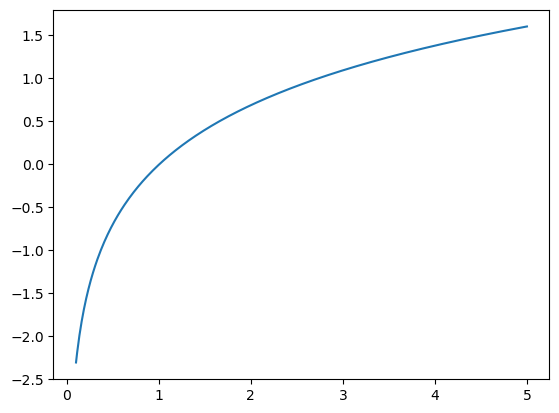

Root (Bracket Method): 1.0067606980333272
Root (Newton's Method): 1.006760698033684


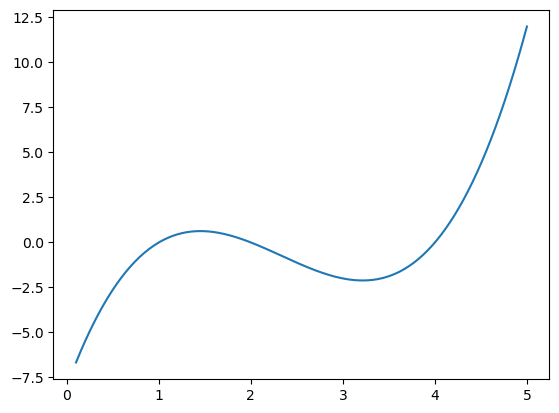

All roots (from np.roots): [1. 2. 4.]
Root 1 (Bracket Method): 0.9999999999999999
Root 2 (Bracket Method): 2.000000000000001
Root 3 (Bracket Method): 3.9999999999999982
Root 3 (Newton's Method): 3.9999999999999996


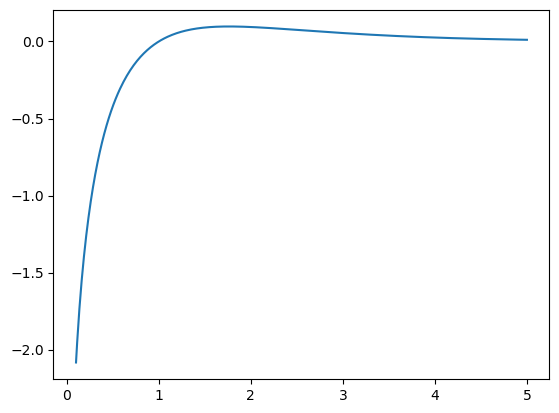

Root (Bracket Method): 1.0
Root (Newton's Method): 1.0


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

x_plot = np.linspace(0.1, 5, 400)

### First function
f1 = lambda x: np.log(x) - np.exp(-5)
f1_prime = lambda x: 1/x

# Graph
y_f1 = f1(x_plot)
plt.figure
plt.plot(x_plot, y_f1)
plt.show(block=True)

# Bracket
sol1_bracket = optimize.root_scalar(f1, bracket=[1.0, 1.1])
print(f"Root (Bracket Method): {sol1_bracket.root}")

# Newton
sol1_newton = optimize.root_scalar(f1, fprime=f1_prime, x0=1.0, method='newton')
print(f"Root (Newton's Method): {sol1_newton.root}")

### Second function
f2 = lambda x: x**3 - 7*x**2 + 14*x - 8
f2_prime = lambda x: 3*x**2 - 14*x + 14

# Graph
y_f2 = f2(x_plot)
plt.figure
plt.plot(x_plot, y_f2)
plt.show(block=True)

# Bracket
poly_roots = np.roots([1, -7, 14, -8])
print(f"All roots (from np.roots): {np.sort(poly_roots)}")
# Root 1
sol2_r1 = optimize.root_scalar(f2, bracket=[0.5, 1.5])
print(f"Root 1 (Bracket Method): {sol2_r1.root}")
# Root 2
sol2_r2 = optimize.root_scalar(f2, bracket=[1.5, 2.5])
print(f"Root 2 (Bracket Method): {sol2_r2.root}")
# Root 3
sol2_r3 = optimize.root_scalar(f2, bracket=[3.5, 4.5])
print(f"Root 3 (Bracket Method): {sol2_r3.root}")

# Newton
sol2_r3_newton = optimize.root_scalar(f2, fprime=f2_prime, x0=4.1, method='newton')
print(f"Root 3 (Newton's Method): {sol2_r3_newton.root}")

### Third Function
f3 = lambda x: np.log(x) * np.exp(-x)
f3_prime = lambda x: (1/x - np.log(x)) * np.exp(-x)

# Graph
y_f3 = f3(x_plot)
plt.plot(x_plot, y_f3)
plt.show(block=True)

# Bracket
sol3_bracket = optimize.root_scalar(f3, bracket=[0.5, 1.5])
print(f"Root (Bracket Method): {sol3_bracket.root}")

# Newton
sol3_newton = optimize.root_scalar(f3, fprime=f3_prime, x0=1.1, method='newton')
print(f"Root (Newton's Method): {sol3_newton.root}")


## Problem 2 (25 points):
You have a 4x4 2D array with two missing values (NaNs).
 Use linear interpolation to fill in the missing values. 
 Use numpy and scipy.interpolate.griddata (or another suitable method) 
 to complete the task.
 

In [14]:
from scipy import interpolate
import numpy as np

data = np.array([
    [1, 2, 3, 4],
    [5, 6, np.NaN, 8],
    [9, 10, 11, 12],
    [13, np.NaN, 15, 16]
])

rows, cols = np.indices(data.shape)
mask = ~np.isnan(data)
points = np.stack([rows[mask], cols[mask]], axis = 1)
values = data[mask]

unknown_mask = np.isnan(data)
unknown_points = np.stack([rows[unknown_mask], cols[unknown_mask]], axis = 1)
interpolated_values = interpolate.griddata(points, values, unknown_points, method='linear')

data_filled = data.copy()
data_filled[unknown_mask] = interpolated_values

print("Original Data")
print(data, "\n")
print("Filled Data")
print(data_filled)

Original Data
[[ 1.  2.  3.  4.]
 [ 5.  6. nan  8.]
 [ 9. 10. 11. 12.]
 [13. nan 15. 16.]] 

Filled Data
[[ 1.  2.  3.  4.]
 [ 5.  6.  7.  8.]
 [ 9. 10. 11. 12.]
 [13. 14. 15. 16.]]


## Problem 2 (30 points)

As a bioenegener or biocoputational enegener you are provided with an image, `HeadCT.png`, which contains some bad pixels that appear as ring artifacts that is commonly seen in CT images. Your task is to use Python libraries like `numpy` and `scipy` (specifically, `scipy.interpolate.griddata` to correct these bad pixels.

### Requirements:
1. **Identify the bad pixels**: Detect the regions where the pixel values are significantly different from surrounding pixels or follow a pattern indicative of the vertical stripes.
2. **Apply Interpolation**: Use `scipy.interpolate.griddata` to estimate values for these bad pixels based on the surrounding good pixels.
3. **Output**: Return the corrected image data or display the corrected image to verify the interpolation quality visually.


Type: <class 'numpy.ndarray'>
Shape: (880, 770)
Data type: uint8


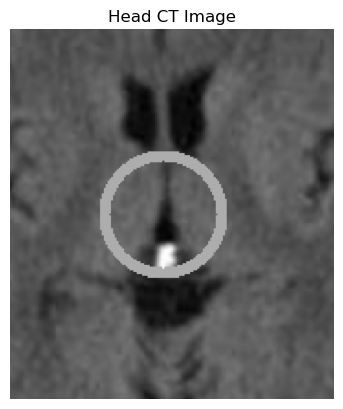

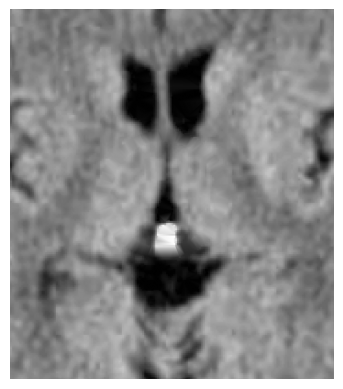

In [26]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# ---- Load and convert to numpy array ----
image_path = 'HeadCT.png'

img = Image.open(image_path).convert('L')   # convert to grayscale
img_np = np.array(img)                      # to numpy array

# ---- Print basic info ----
print("Type:", type(img_np))
print("Shape:", img_np.shape)
print("Data type:", img_np.dtype)

# ---- Plot the image ----
plt.imshow(img_np, cmap='gray')
plt.title("Head CT Image")
plt.axis('off')
plt.show()

BRIGHT_THRESHOLD = 150
DARK_THRESHOLD = 20

bad_mask = (img_np > BRIGHT_THRESHOLD) | (img_np < DARK_THRESHOLD)
good_mask = ~bad_mask
rows, cols = np.indices(img_np.shape)

known_points = np.stack([rows[good_mask], cols[good_mask]], axis=1)
known_values = img_np[good_mask]
unknown_points = np.stack([rows[bad_mask], cols[bad_mask]], axis=1)
interpolated_values = interpolate.griddata(known_points, known_values, unknown_points, method='linear')

corrected_img_np = img_np.copy()
corrected_img_np[bad_mask] = interpolated_values

plt.imshow(corrected_img_np, cmap='gray')
plt.axis('off')
plt.show()